# REINFORCE + learned baseline vs vanilla REINFORCE (CartPole-v1)

**Start here only after** the standalone notebook **`reinforce_cartpole_vanilla.ipynb`**, which implements **vanilla REINFORCE** (one policy network, gradient weights $G_t$).

This notebook runs **two** algorithms side by side:
1. **Vanilla REINFORCE** — same mathematical setup as the vanilla notebook (weights $\propto G_t$).
2. **REINFORCE + learned baseline** — adds a **value network** $V_\phi(s)$ and replaces $G_t$ by the **advantage** $A_t = G_t - V_\phi(s_t)$, with extra supervision on $V_\phi$.

---

### Quick reference: what changes vs vanilla?

| | **Vanilla** (`reinforce_cartpole_vanilla.ipynb`) | **This notebook (baseline + advantage)** |
|---|---|---|
| **Networks** | Policy $\pi_\theta$ only | Policy $\pi_\theta$ **+** state-value **$V_\phi(s)$** |
| **Gradient weights** | Monte Carlo returns $G_t$ | **Advantages** $A_t = G_t - V_\phi(s_t)$ |
| **Policy loss** | $-\sum_t \log\pi_\theta \, G_t$ | $-\sum_t \log\pi_\theta \, A_t$ |
| **Extra loss** | — | **Value regression:** $\mathrm{MSE}(V_\phi(s_t), G_t)$ |
| **Training step** | One optimizer on $\theta$ | **Two** optimizers: $\theta$ and $\phi$ |
| **Trajectory data** | Rewards + log-probs | Also store **every state** for $V_\phi(s_t)$ |

Uses **Gymnasium** and **PyTorch**. Vanilla uses raw discounted returns $G_t$. With baseline, the policy uses raw advantages $A_t = G_t - V_\phi(s_t)$ (no trajectory whitening); $V_\phi$ is trained with Monte Carlo targets.


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 2. Hyperparameters

**Vs vanilla notebook:** vanilla uses a single `LR` for the policy. Here **`LR_POLICY`** plays that same role; **`LR_VALUE`** is **only for the baseline network** (does not exist in vanilla).

In [2]:
ENV_ID = "CartPole-v1"
GAMMA = 0.99
HIDDEN = 128
NUM_EPISODES = 800
PRINT_EVERY = 100

LR_POLICY = 1e-2       # policy step size (matches vanilla notebook LR)
LR_VALUE = 2e-2      # value net learning rate

SMOOTH = 50            

## 3. Networks

**`Policy`** — identical role to the vanilla notebook.

**`ValueNet`** — **not present in vanilla.** Maps state → scalar baseline $V_\phi(s)$ used to form advantages.

In [3]:
class Policy(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ValueNet(nn.Module):
    """NEW vs vanilla: state-value baseline V_phi(s)."""

    def __init__(self, obs_dim: int, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

## 4. Warm-up: why subtract a baseline?

Toy illustration — noisy returns $G$ vs centered $G - b$. Same idea as using $A_t = G_t - V(s_t)$ when $V$ estimates typical return from $s$.

Var(G)   = 222.93
Var(G-b) = 222.93


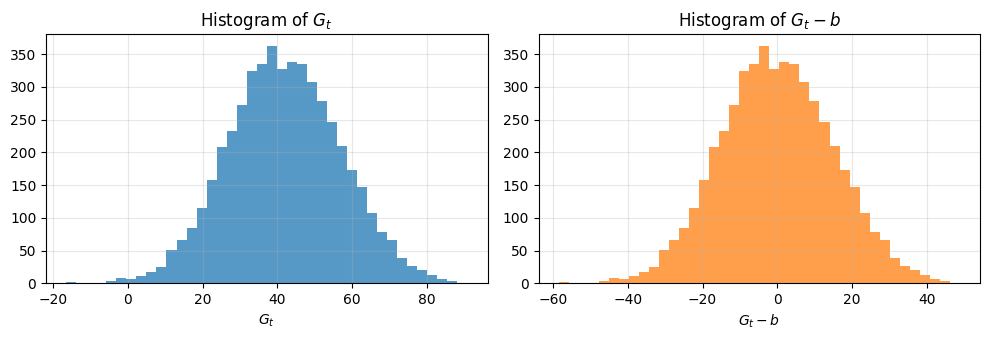

In [4]:
rng = np.random.default_rng(0)
n = 5_000
mean_return = 42.0
G = mean_return + rng.normal(0.0, 15.0, size=n)
b = mean_return
A = G - b

print(f"Var(G)   = {G.var():.2f}")
print(f"Var(G-b) = {A.var():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(G, bins=40, alpha=0.75, color="C0")
ax[0].set_title("Histogram of $G_t$")
ax[0].set_xlabel("$G_t$")
ax[1].hist(A, bins=40, alpha=0.75, color="C1")
ax[1].set_title("Histogram of $G_t - b$")
ax[1].set_xlabel("$G_t - b$")
for a in ax:
    a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Episode updates

### Branch A — vanilla REINFORCE (matches `reinforce_cartpole_vanilla.ipynb`)

- Collect `log_probs` and `rewards`.
- Compute $G_t$. **Loss:** `-sum(log_prob * G_t)`.
- **One** backward + **one** optimizer step.

### Branch B — NEW: advantages + value fitting

| Step | Vanilla | With baseline |
|---|---|---|
| During rollout | Only store log-probs + rewards | **Also append each `obs` to `states`** |
| After rollout | `G = discounted_returns_raw(...)` | Same `G`, plus **`V = value(states)`**, **`A = G - V.detach()`** |
| Policy gradient | Multiply log-prob by **`G`** | Multiply log-prob by **`A`** (not $G$) |
| Baseline training | — | **`MSE(V, G)`** so $V_\phi \approx \mathbb{E}[G_t\mid s_t]$ |
| Optimizer | One | **Two** (`policy_opt`, `value_opt`) |

**Why `V.detach()` in `A = G - V.detach()`?** The policy loss must not push gradients into $\phi$ through the baseline; $\phi$ learns only from the value loss.

In [5]:
def discounted_returns_raw(rewards: list[float], gamma: float) -> torch.Tensor:
    """Monte Carlo returns G_t (shared by both branches)."""
    G = 0.0
    out: list[float] = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return torch.tensor(out, dtype=torch.float32, device=device)


def run_episode_vanilla(
    env: gym.Env,
    policy: Policy,
    opt: optim.Optimizer,
    gamma: float,
    train: bool,
) -> tuple[float, float]:
    """Same logic as reinforce_cartpole_vanilla.ipynb (plus Var(G) logging for plots)."""
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    obs, _ = env.reset()
    done = False
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(float(reward))
        done = terminated or truncated

    ep_ret = float(sum(rewards))
    if not train or not log_probs:
        return ep_ret, float("nan")

    G = discounted_returns_raw(rewards, gamma)
    var_w = G.var().item() if len(G) > 1 else 0.0
    loss = -(torch.stack(log_probs) * G).sum()  # vanilla: weights are G_t
    opt.zero_grad()
    loss.backward()
    opt.step()
    return ep_ret, var_w


def run_episode_advantage(
    env: gym.Env,
    policy: Policy,
    value: ValueNet,
    policy_opt: optim.Optimizer,
    value_opt: optim.Optimizer,
    gamma: float,
    train: bool,
) -> tuple[float, float]:
    """REINFORCE with state-dependent baseline: A_t = G_t - V(s_t); value loss MSE(V, G)."""
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    states: list[np.ndarray] = []
    obs, _ = env.reset()
    done = False
    while not done:
        states.append(np.asarray(obs, dtype=np.float32))  # NEW: needed for V_phi(s_t)
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(float(reward))
        done = terminated or truncated

    ep_ret = float(sum(rewards))
    if not train or not log_probs:
        return ep_ret, float("nan")

    G = discounted_returns_raw(rewards, gamma)
    states_t = torch.tensor(np.stack(states), dtype=torch.float32, device=device)
    V = value(states_t)
    A = G - V.detach()  # advantage A_t = G_t - V(s_t); detach so policy loss does not train phi
    var_w = A.var().item() if len(A) > 1 else 0.0

    policy_loss = -(torch.stack(log_probs) * A).sum()
    value_loss = F.mse_loss(V, G)  # NEW: train baseline toward Monte Carlo returns

    policy_opt.zero_grad()
    value_opt.zero_grad()
    policy_loss.backward()
    value_loss.backward()
    policy_opt.step()
    value_opt.step()

    return ep_ret, var_w


## 6. Train both (matched policy initialization)

`torch.manual_seed(SEED)` before each run gives **identical initial policy weights**; runs differ because vanilla updates with $G_t$ only while the second run also updates $V_\phi$ and uses $A_t$.

In [6]:
def train_vanilla() -> tuple[list[float], list[float]]:
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    torch.manual_seed(SEED)
    policy = Policy(obs_dim, n_actions).to(device)
    opt = optim.Adam(policy.parameters(), lr=LR_POLICY)
    rets: list[float] = []
    ivars: list[float] = []
    for ep in range(1, NUM_EPISODES + 1):
        r, vw = run_episode_vanilla(env, policy, opt, GAMMA, train=True)
        rets.append(r)
        ivars.append(vw)
        if ep == 1 or ep % PRINT_EVERY == 0:
            w = rets[-PRINT_EVERY:]
            print(f"[vanilla] {ep:5d} | return {r:6.1f} | mean {np.mean(w):6.1f}")
    env.close()
    return rets, ivars


def train_advantage() -> tuple[list[float], list[float], Policy]:
    env = gym.make(ENV_ID)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    torch.manual_seed(SEED)
    policy = Policy(obs_dim, n_actions).to(device)
    value = ValueNet(obs_dim).to(device)
    p_opt = optim.Adam(policy.parameters(), lr=LR_POLICY)
    v_opt = optim.Adam(value.parameters(), lr=LR_VALUE)
    rets: list[float] = []
    ivars: list[float] = []
    for ep in range(1, NUM_EPISODES + 1):
        r, vw = run_episode_advantage(env, policy, value, p_opt, v_opt, GAMMA, train=True)
        rets.append(r)
        ivars.append(vw)
        if ep == 1 or ep % PRINT_EVERY == 0:
            w = rets[-PRINT_EVERY:]
            print(f"[advantage] {ep:5d} | return {r:6.1f} | mean {np.mean(w):6.1f}")
    env.close()
    return rets, ivars, policy


returns_v, within_var_v = train_vanilla()
returns_a, within_var_a, policy_adv = train_advantage()

[vanilla]     1 | return   14.0 | mean   14.0
[vanilla]   100 | return   13.0 | mean   18.6
[vanilla]   200 | return   65.0 | mean   28.7
[vanilla]   300 | return  100.0 | mean  170.9
[vanilla]   400 | return  137.0 | mean  214.9
[vanilla]   500 | return   85.0 | mean   73.2
[vanilla]   600 | return   75.0 | mean   78.8
[vanilla]   700 | return   70.0 | mean   74.7
[vanilla]   800 | return  500.0 | mean  157.7
[advantage]     1 | return   29.0 | mean   29.0
[advantage]   100 | return   36.0 | mean   12.2
[advantage]   200 | return  106.0 | mean   39.9
[advantage]   300 | return   66.0 | mean   50.4
[advantage]   400 | return  500.0 | mean  292.0
[advantage]   500 | return  500.0 | mean  491.5
[advantage]   600 | return  500.0 | mean  480.6
[advantage]   700 | return  500.0 | mean  492.4
[advantage]   800 | return  500.0 | mean  498.7


## 7. Comparison plots ($\mathrm{Var}_t(G_t)$ vs $\mathrm{Var}_t(A_t)$)

While $V_\phi$ is still wrong, $\mathrm{Var}(A)$ can exceed $\mathrm{Var}(G)$; late in training, $\mathrm{Var}(A)$ often drops when $V_\phi$ tracks returns. Ratio $\mathrm{Var}(A)/\mathrm{Var}(G)$ on a symlog scale (horizontal line at 1).

Mean within-episode variance of scalar weights along each trajectory:
  episodes    0– 199:  mean Var(G)=   46.65   mean Var(A)=   51.03
  episodes  200– 399:  mean Var(G)=  436.88   mean Var(A)=  173.07
  episodes  400– 599:  mean Var(G)=  236.79   mean Var(A)=  407.04
  episodes  600– 799:  mean Var(G)=  300.50   mean Var(A)=  514.55

Last 200 episodes: mean Var(G)=300.4953, mean Var(A)=514.5491


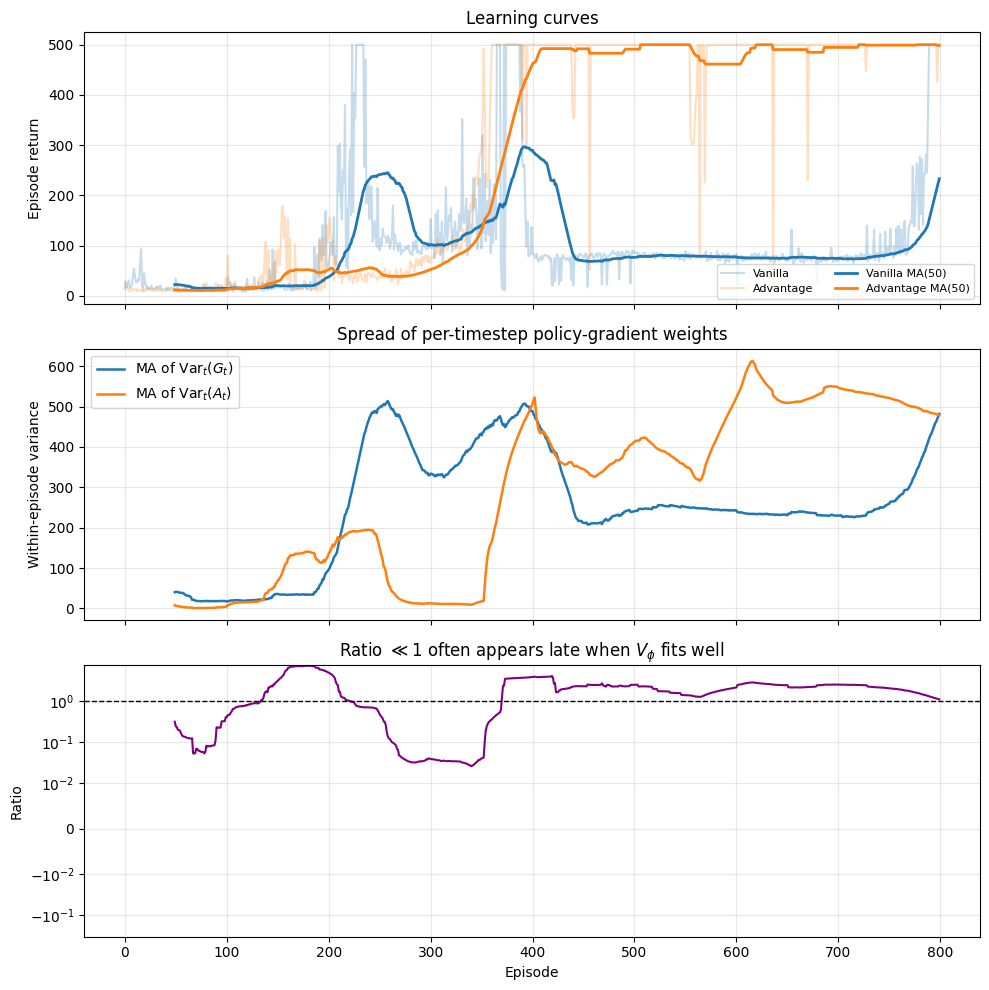

In [7]:
rv = np.asarray(returns_v, dtype=np.float64)
ra = np.asarray(returns_a, dtype=np.float64)
iv_v = np.asarray(within_var_v, dtype=np.float64)
iv_a = np.asarray(within_var_a, dtype=np.float64)

smooth = np.ones(SMOOTH) / SMOOTH
ma_x = np.arange(SMOOTH - 1, NUM_EPISODES)
iv_v_s = np.convolve(iv_v, smooth, mode="valid")
iv_a_s = np.convolve(iv_a, smooth, mode="valid")
ratio = iv_a / (iv_v + 1e-8)
ratio_s = np.convolve(ratio, smooth, mode="valid")

bin_w = 200
print("Mean within-episode variance of scalar weights along each trajectory:")
for start in range(0, NUM_EPISODES, bin_w):
    end = min(start + bin_w, NUM_EPISODES)
    print(
        f"  episodes {start:4d}–{end - 1:4d}:  mean Var(G)={iv_v[start:end].mean():8.2f}   mean Var(A)={iv_a[start:end].mean():8.2f}"
    )
print(
    f"\nLast {bin_w} episodes: mean Var(G)={iv_v[-bin_w:].mean():.4f}, mean Var(A)={iv_a[-bin_w:].mean():.4f}"
)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(rv, alpha=0.25, color="C0", label="Vanilla")
axes[0].plot(ra, alpha=0.25, color="C1", label="Advantage")
axes[0].plot(ma_x, np.convolve(rv, smooth, mode="valid"), color="C0", lw=2, label=f"Vanilla MA({SMOOTH})")
axes[0].plot(ma_x, np.convolve(ra, smooth, mode="valid"), color="C1", lw=2, label=f"Advantage MA({SMOOTH})")
axes[0].set_ylabel("Episode return")
axes[0].set_title("Learning curves")
axes[0].legend(loc="lower right", ncol=2, fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ma_x, iv_v_s, color="C0", lw=1.8, label=r"MA of $\mathrm{Var}_t(G_t)$")
axes[1].plot(ma_x, iv_a_s, color="C1", lw=1.8, label=r"MA of $\mathrm{Var}_t(A_t)$")
axes[1].set_ylabel("Within-episode variance")
axes[1].set_title("Spread of per-timestep policy-gradient weights")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ma_x, ratio_s, color="purple", lw=1.5, label=r"MA of $\mathrm{Var}(A)/\mathrm{Var}(G)$")
axes[2].axhline(1.0, color="k", ls="--", lw=1)
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Ratio")
axes[2].set_title(r"Ratio $\ll 1$ often appears late when $V_{\phi}$ fits well")
axes[2].set_yscale("symlog", linthresh=1e-2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Policy video (advantage-trained policy)

Uses **`policy_adv`** from §6 (the run with baseline + advantages).

In [8]:
def record_policy_video(
    policy: Policy,
    env_id: str,
    max_steps: int = 500,
    seed: int = 123,
) -> list[np.ndarray]:
    env = gym.make(env_id, render_mode="rgb_array")
    frames: list[np.ndarray] = []
    obs, _ = env.reset(seed=seed)
    done = False
    steps = 0
    policy.eval()
    with torch.no_grad():
        while not done and steps < max_steps:
            frames.append(env.render())
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = policy(obs_t)
            action = int(torch.argmax(logits, dim=1).item())
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
    env.close()
    policy.train()
    return frames


def animate_frames(frames: list[np.ndarray], interval_ms: int = 40) -> HTML:
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes([0, 0, 1, 1], frameon=False)
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(i: int):
        im.set_data(frames[i])
        return (im,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


video_frames = record_policy_video(policy_adv, ENV_ID)
print(f"Greedy rollout: {len(video_frames)} steps.")
display(animate_frames(video_frames))

Greedy rollout: 500 steps.


**Note:** CartPole-v1 truncates after 500 steps. Tune `NUM_EPISODES`, `LR_POLICY`, or `LR_VALUE` if needed.